In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw

In [2]:
import sys
import os

# Get the absolute path of the root project directory (parent of the 'notebooks' folder)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the 'scripts' folder to sys.path
sys.path.append(os.path.join(project_root, 'scripts'))

# Now import the data_loader module
from data_loader import Dataloader
from eda import ExploratoryDataAnalysis
from featurise import FeatureExtractor

In [3]:
# Load datasets
df = pd.read_csv("../data/bbb.csv")
df_train = pd.read_csv("../data/bbb_train.csv")
df_test = pd.read_csv("../data/bbb_test.csv")
df_val = pd.read_csv("../data/bbb_valid.csv")

In [4]:
# Display first few rows
df.head()

,Drug_ID,Drug,Y
0,Propanolol,CC(C)NCC(O)COc1cccc2ccccc12.[Cl],1
1,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
2,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
3,24,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,1
4,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1


In [5]:
# Check dataset info
print("\nOverall Dataset Info:")
df.info()


Overall Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Drug_ID  2030 non-null   object
 1   Drug     2030 non-null   object
 2   Y        2030 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 47.7+ KB


In [6]:

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Drug_ID    0
Drug       0
Y          0
dtype: int64


In [7]:
# Check unique values per column
print("\nUnique Values Per Column:\n", df.nunique())


Unique Values Per Column:
 Drug_ID    2018
Drug       1975
Y             2
dtype: int64


In [8]:
# Summary statistics
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
                 Y
count  2030.000000
mean      0.764039
std       0.424702
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000


In [9]:
# Check sizes of each split
print(f"Train set size: {df_train.shape}")
print(f"Test set size: {df_test.shape}")
print(f"Validation set size: {df_val.shape}")

Train set size: (1421, 3)
Test set size: (406, 3)
Validation set size: (203, 3)


## **1. Label Distribution (0 = Non-permeable, 1 = Permeable)**  
**What are we looking at?**  
- This chart shows how many molecules in our dataset belong to each category:  
  - **0 (Non-permeable)** → Molecules that **cannot** cross the blood-brain barrier.  
  - **1 (Permeable)** → Molecules that **can** cross the blood-brain barrier.  

**Why is this important?**  
- Our machine learning model might not learn appropriately if the dataset is **imbalanced** (one label appears much more often than the other).  
- This helps us decide if we need **data balancing techniques** before training the model.  

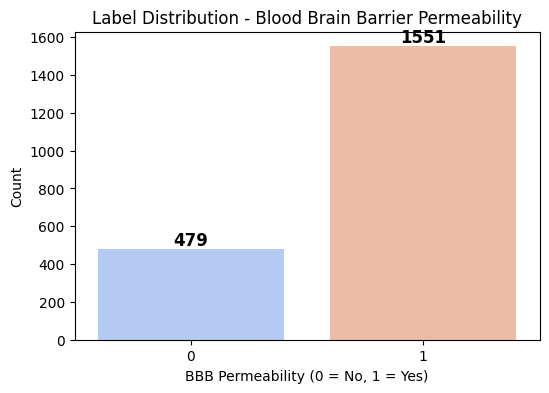

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is df
plt.figure(figsize=(6, 4))

# Plot countplot using seaborn
ax = sns.countplot(x='Y', data=df, palette="coolwarm")

# Add numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Set labels and title
plt.xlabel("BBB Permeability (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Label Distribution - Blood Brain Barrier Permeability")

# Display the plot
plt.show()


## **2. SMILES Length Distribution (Molecular Complexity)**  
**What are we looking at?**  
- SMILES (Simplified Molecular Input Line Entry System) is a way to represent molecules as a string of text.  
- This histogram shows how long these SMILES strings are in our dataset.  

**Why is this important?**  
- Longer SMILES strings usually mean **more complex molecules**.  
- If most molecules are **very short or very long**, it might affect how well our model understands them.  

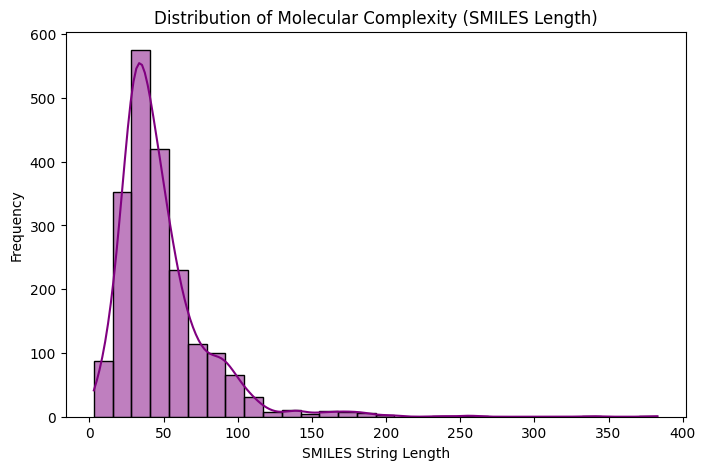

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a new column for SMILES length
df["SMILES_Length"] = df["Drug"].apply(len)

# Plotting the SMILES Length distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["SMILES_Length"], bins=30, kde=True, color="purple")

# Adding labels and title
plt.xlabel("SMILES String Length")
plt.ylabel("Frequency")
plt.title("Distribution of Molecular Complexity (SMILES Length)")

# Show the plot
plt.show()

## **3. Visualizing Molecular Structures (First 6 Molecules)**  
**What are we looking at?**  
- Instead of just seeing text-based SMILES representations, we will **draw the first 6 molecules** in our dataset.  
- This helps us **visually inspect** the types of molecules we are working with.  

**Why is this important?**  
- It gives us an **intuitive feel** for the molecular structures in the dataset.  
- If molecules look **very similar**, our model might struggle to tell them apart.  
- If molecules look **very different**, our model might need more data to learn general patterns.

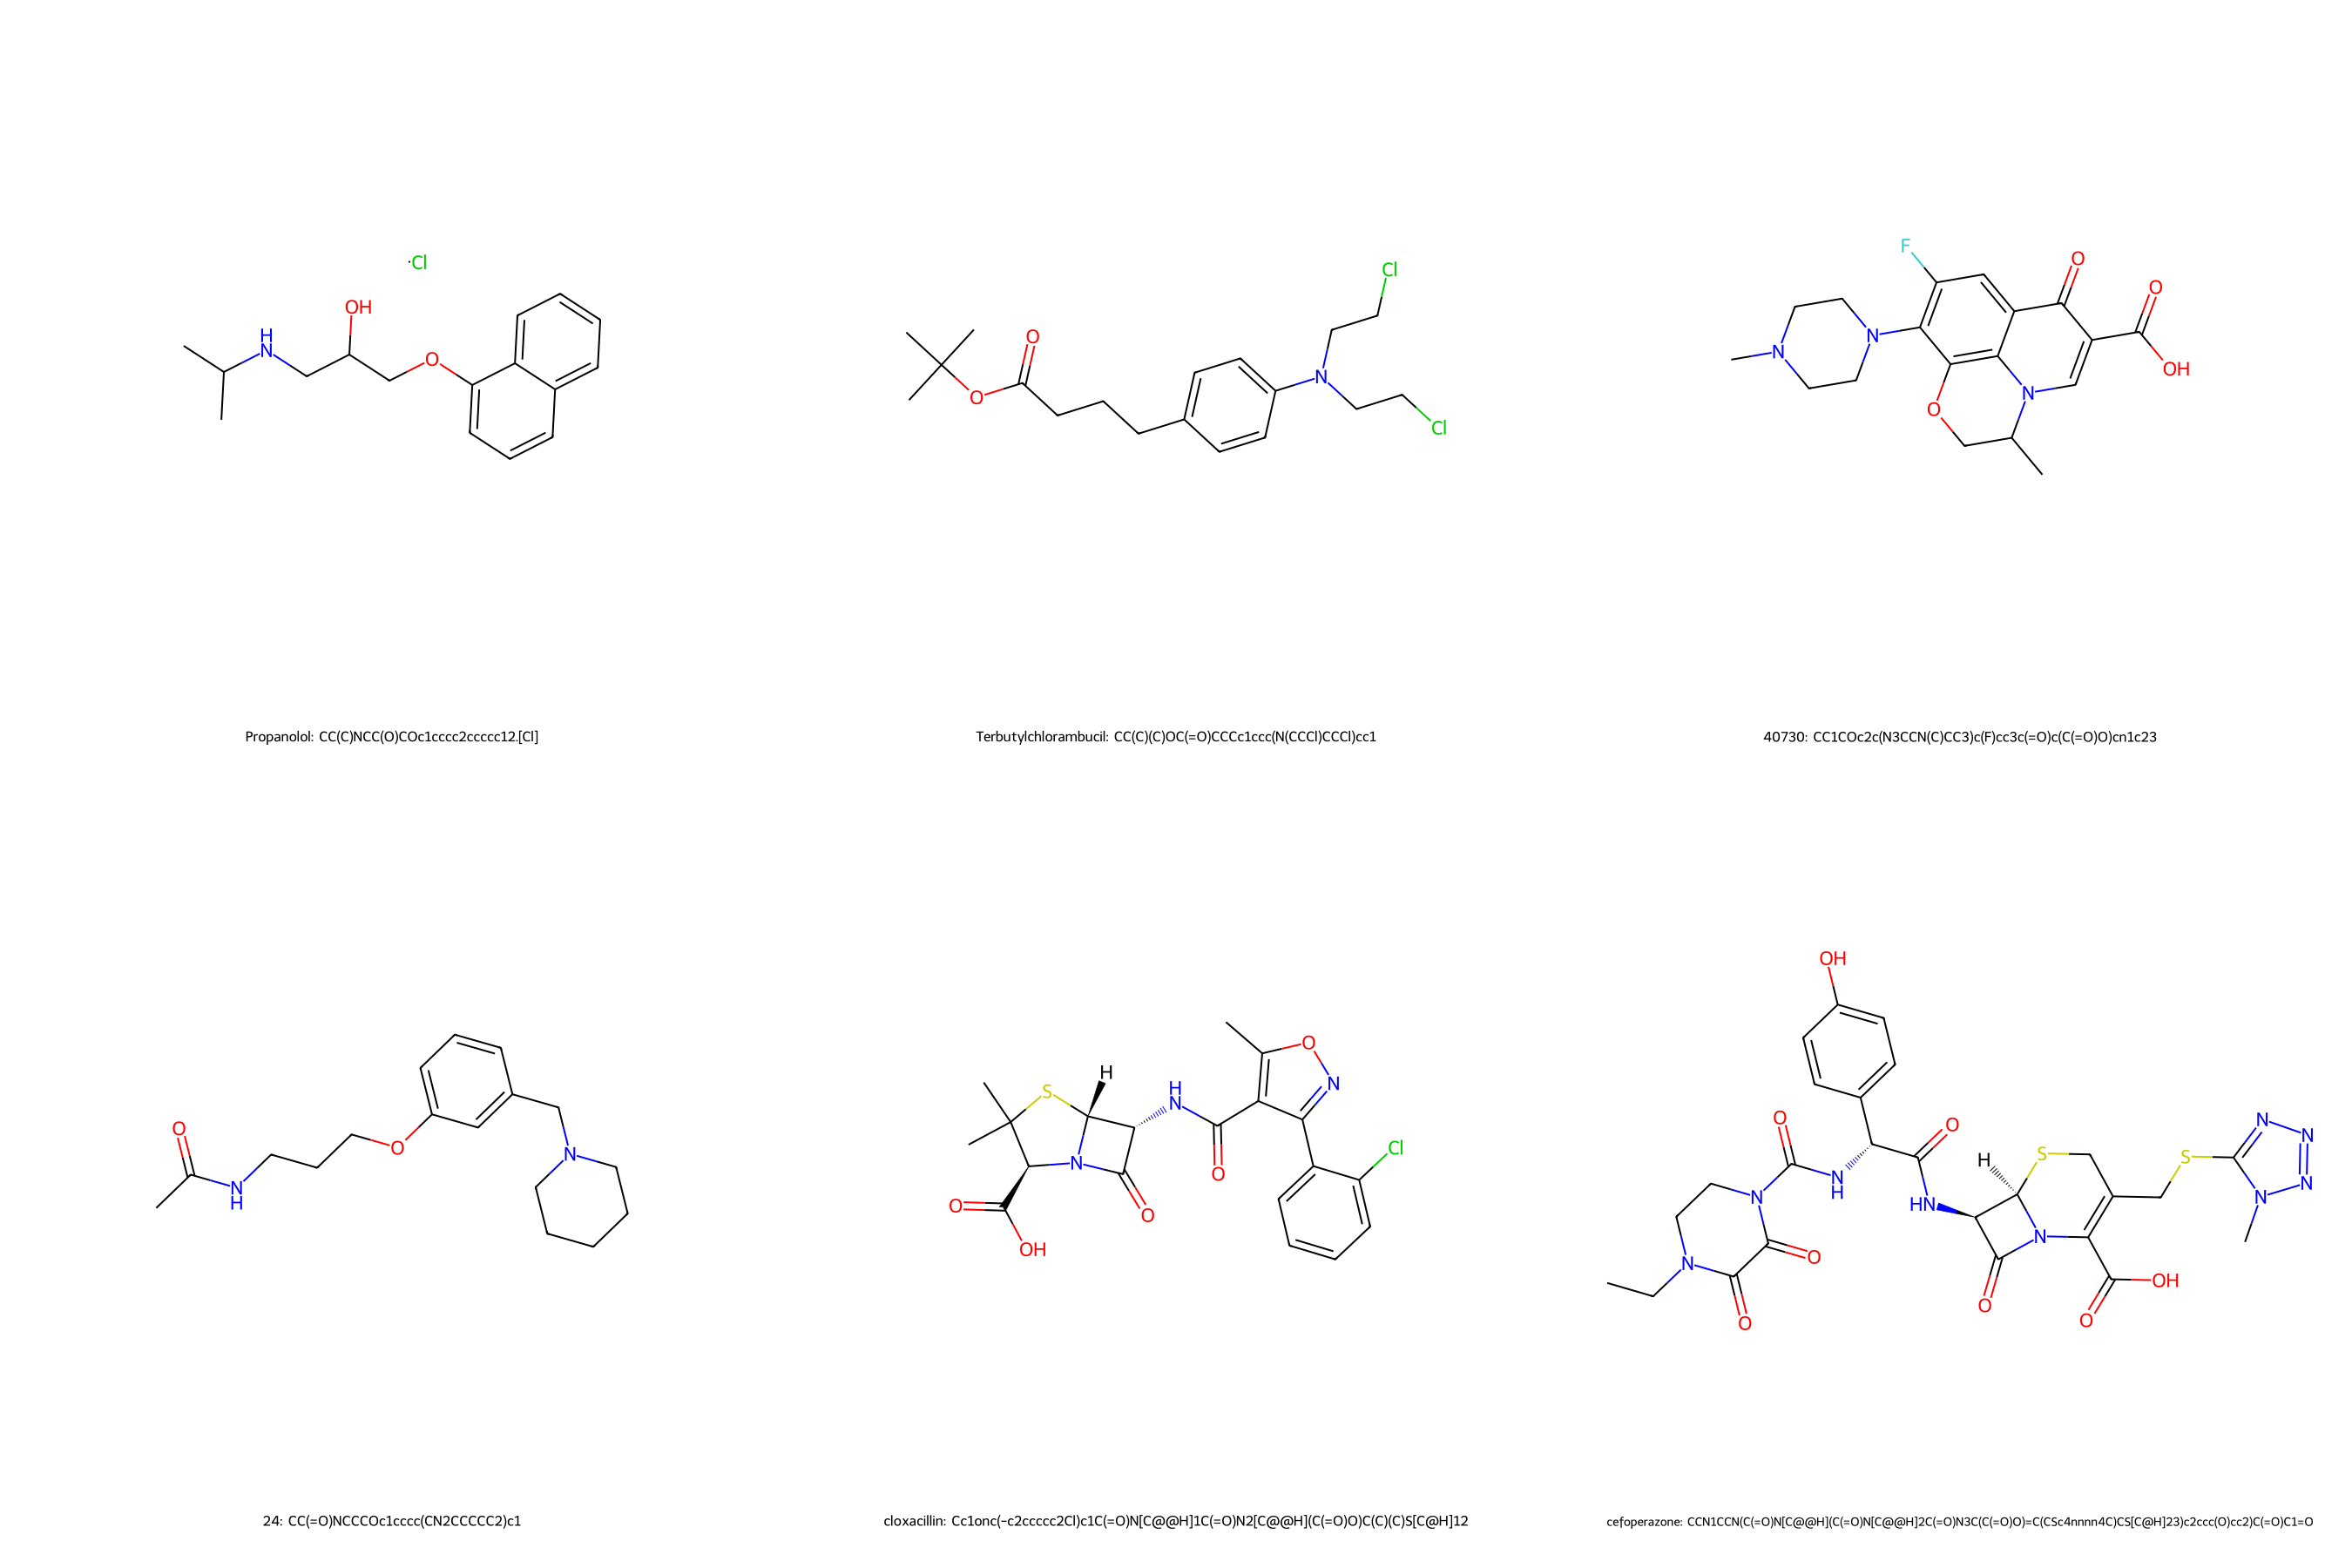

In [26]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# Select first 6 molecules
smiles_list = df["Drug"].iloc[:6].tolist()
drug_ids = df["Drug_ID"].iloc[:6].astype(str).tolist()  # Convert IDs to strings
drug_names = df["Drug"].iloc[:6].tolist()  # Get drug names

# Convert SMILES to molecular structures
mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]

# Create labels using Drug ID and Name
labels = [f"{drug_id}: {drug_name}" for drug_id, drug_name in zip(drug_ids, drug_names)]

# Generate grid image with labels
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(900, 900), legends=labels)

# Display the image
display(img)